In [1]:
# =========================
# 0) Imports & Setup
# =========================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report
import itertools


In [2]:
# =========================
# 1) Load MNIST Dataset
# =========================

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape :", x_test.shape, y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) (60000,)
Test shape : (10000, 28, 28) (10000,)


In [3]:
# =========================
# 2) Data Preprocessing
# =========================

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# For CNN: add channel dimension -> (28, 28, 1)
x_train_cnn = np.expand_dims(x_train, axis=-1)
x_test_cnn  = np.expand_dims(x_test, axis=-1)

# One-hot encode labels for training (categorical)
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test, num_classes)

print("CNN input shape:", x_train_cnn.shape)


CNN input shape: (60000, 28, 28, 1)


In [4]:
# =========================
# 3) Model 1: MLP (Baseline)
# =========================

mlp_model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),                               # Convert 2D image to 1D vector
    layers.Dense(128, activation="relu"),           # Hidden layer 1
    layers.Dense(64, activation="relu"),            # Hidden layer 2
    layers.Dense(num_classes, activation="softmax") # Output layer
])

mlp_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mlp_model.summary()

history_mlp = mlp_model.fit(
    x_train, y_train_cat,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

mlp_test_loss, mlp_test_acc = mlp_model.evaluate(x_test, y_test_cat, verbose=0)
print(f"MLP Test Accuracy: {mlp_test_acc*100:.2f}%")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8737 - loss: 0.4432 - val_accuracy: 0.9647 - val_loss: 0.1203
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9657 - loss: 0.1101 - val_accuracy: 0.9707 - val_loss: 0.0989
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9782 - loss: 0.0724 - val_accuracy: 0.9757 - val_loss: 0.0799
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9813 - loss: 0.0589 - val_accuracy: 0.9782 - val_loss: 0.0874
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9877 - loss: 0.0395 - val_accuracy: 0.9780 - val_loss: 0.0781
MLP Test Accuracy: 97.87%


In [5]:
# =========================
# 4) Model 2: CNN (Main Model)
# =========================

cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

history_cnn = cnn_model.fit(
    x_train_cnn, y_train_cat,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc*100:.2f}%")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 35ms/step - accuracy: 0.9010 - loss: 0.3136 - val_accuracy: 0.9868 - val_loss: 0.0446
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.9853 - loss: 0.0455 - val_accuracy: 0.9885 - val_loss: 0.0428
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - accuracy: 0.9904 - loss: 0.0301 - val_accuracy: 0.9895 - val_loss: 0.0354
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9931 - loss: 0.0226 - val_accuracy: 0.9888 - val_loss: 0.0410
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9946 - loss: 0.0151 - val_accuracy: 0.9907 - val_loss: 0.0373
CNN Test Accuracy: 99.15%


In [6]:
# =========================
# 5) Predictions + Confusion Matrix
# =========================

# Softmax probabilities from CNN
probs = cnn_model.predict(x_test_cnn, verbose=0)

# Predicted classes
y_pred = np.argmax(probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[ 973    1    0    0    1    0    4    1    0    0]
 [   0 1132    0    0    0    1    0    1    1    0]
 [   1    0 1019    2    2    0    0    6    2    0]
 [   0    0    2  999    0    7    0    0    2    0]
 [   0    0    0    0  978    0    1    0    0    3]
 [   0    0    1    4    0  886    1    0    0    0]
 [   1    2    0    0    4    2  946    0    3    0]
 [   0    4    2    0    3    1    0 1016    0    2]
 [   2    0    1    1    0    0    0    1  968    1]
 [   0    0    0    1    4    4    0    0    2  998]]


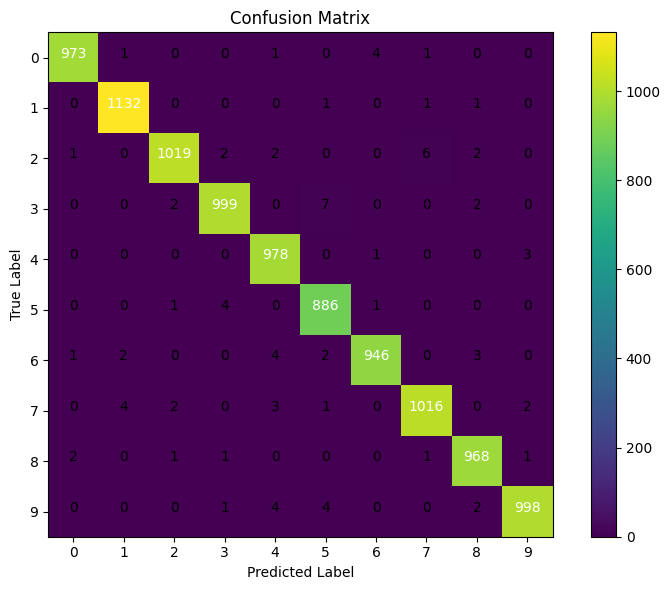

In [7]:
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    # Write values inside cells
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

plot_confusion_matrix(cm, classes=list(range(10)))
plt.show()


Total misclassified: 85


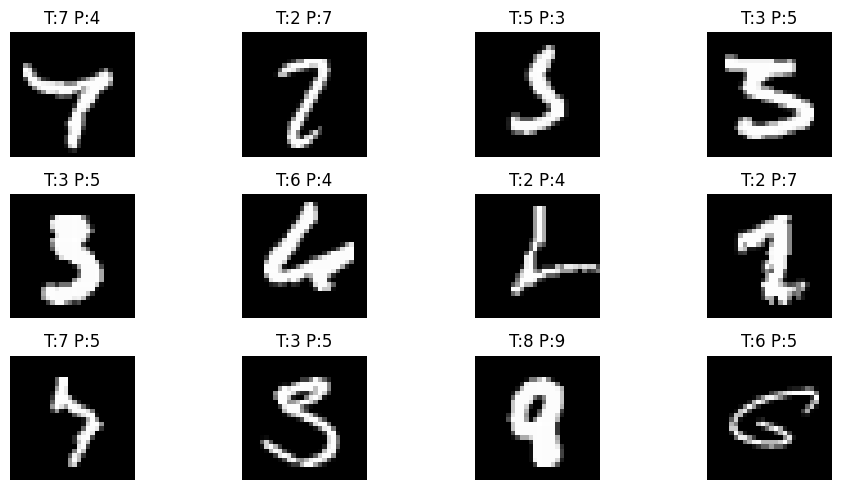

In [8]:
# =========================
# 6) Error Analysis (show some misclassified examples)
# =========================

mis_idx = np.where(y_pred != y_test)[0]
print("Total misclassified:", len(mis_idx))

# Show 12 misclassified images
plt.figure(figsize=(10, 5))
for i, idx in enumerate(mis_idx[:12]):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(f"T:{y_test[idx]} P:{y_pred[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [9]:
# =========================
# 7) Fuzzy Decision Layer
# =========================

def triangular(x, a, b, c):
    """
    Triangular membership function:
    - a: left
    - b: peak
    - c: right
    """
    if x <= a or x >= c:
        return 0.0
    elif a < x < b:
        return (x - a) / (b - a)
    elif b <= x < c:
        return (c - x) / (c - b)
    else:
        return 0.0

def fuzzy_confidence_label(conf):
    """
    Convert confidence value to fuzzy decision:
    - Low, Medium, High using triangular memberships.
    Then pick the label with max membership degree.
    """

    # Define membership functions on [0,1]
    low_mu    = triangular(conf, 0.0, 0.2, 0.5)
    medium_mu = triangular(conf, 0.3, 0.55, 0.8)
    high_mu   = triangular(conf, 0.6, 0.85, 1.0)

    mus = {"Low": low_mu, "Medium": medium_mu, "High": high_mu}
    best_label = max(mus, key=mus.get)
    best_mu = mus[best_label]

    # Apply decision rules
    if best_label == "High":
        decision = "ACCEPT"
    elif best_label == "Medium":
        decision = "NEEDS_REVIEW"
    else:
        decision = "UNCERTAIN"

    return best_label, best_mu, decision

# Compute confidence = max softmax probability for each sample
confidence = np.max(probs, axis=1)

# Apply fuzzy decision layer
fuzzy_levels = []
fuzzy_decisions = []
fuzzy_strength = []

for conf in confidence:
    level, mu, decision = fuzzy_confidence_label(conf)
    fuzzy_levels.append(level)
    fuzzy_strength.append(mu)
    fuzzy_decisions.append(decision)

fuzzy_levels = np.array(fuzzy_levels)
fuzzy_strength = np.array(fuzzy_strength)
fuzzy_decisions = np.array(fuzzy_decisions)

# Quick summary
unique, counts = np.unique(fuzzy_decisions, return_counts=True)
print("Fuzzy Decisions Summary:")
for u, c in zip(unique, counts):
    print(f"{u}: {c}")


Fuzzy Decisions Summary:
ACCEPT: 9938
NEEDS_REVIEW: 61
UNCERTAIN: 1


In [10]:
# =========================
# 8) Decision Quality Analysis
# =========================

# Accuracy only for ACCEPT predictions
accept_idx = np.where(fuzzy_decisions == "ACCEPT")[0]
accept_acc = np.mean(y_pred[accept_idx] == y_test[accept_idx]) if len(accept_idx) > 0 else 0

# Accuracy for NEEDS_REVIEW predictions
review_idx = np.where(fuzzy_decisions == "NEEDS_REVIEW")[0]
review_acc = np.mean(y_pred[review_idx] == y_test[review_idx]) if len(review_idx) > 0 else 0

# Accuracy for UNCERTAIN predictions
uncertain_idx = np.where(fuzzy_decisions == "UNCERTAIN")[0]
uncertain_acc = np.mean(y_pred[uncertain_idx] == y_test[uncertain_idx]) if len(uncertain_idx) > 0 else 0

print(f"ACCEPT count: {len(accept_idx)} | Accuracy: {accept_acc*100:.2f}%")
print(f"NEEDS_REVIEW count: {len(review_idx)} | Accuracy: {review_acc*100:.2f}%")
print(f"UNCERTAIN count: {len(uncertain_idx)} | Accuracy: {uncertain_acc*100:.2f}%")


ACCEPT count: 9938 | Accuracy: 99.44%
NEEDS_REVIEW count: 61 | Accuracy: 54.10%
UNCERTAIN count: 1 | Accuracy: 0.00%


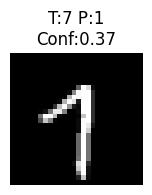

In [11]:
# =========================
# 9) Show some UNCERTAIN examples
# =========================

show_idx = uncertain_idx[:12]

plt.figure(figsize=(10, 5))
for i, idx in enumerate(show_idx):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(f"T:{y_test[idx]} P:{y_pred[idx]}\nConf:{confidence[idx]:.2f}")
    plt.axis("off")
plt.tight_layout()
plt.show()
